# Few-shot learning experiment

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports

In [2]:
import os
import random
import csv
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

from tqdm import tqdm
import time

from PIL import Image, ImageFilter
import cv2


## Reproducibility

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cuda


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [5]:
zip_path = "/content/drive/MyDrive/DLprojekt1/archive.zip"
!unzip -q "/content/drive/MyDrive/DLprojekt1/archive.zip" -d "/content/"

In [6]:
# global variables and creating folders
DATA_DIR = "/content"

PROJECT_DIR = "/content/drive/MyDrive/DLprojekt1"

MODEL_DIR = os.path.join(PROJECT_DIR, "saved_models")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULT_DIR = os.path.join(PROJECT_DIR, "results")
PLOT_DIR = os.path.join(PROJECT_DIR, "plots")

PATIENCE = 5

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)


## Data Loading

In [7]:
def load_few_shot_data(augmentation=None, model_type="mobilenet"):

    train_transform = get_transform(augmentation, model_type)
    test_transform = get_transform(None, model_type)

    train_set = torchvision.datasets.ImageFolder(
        os.path.join(DATA_DIR, "train"),
        transform=train_transform
    )

    val_set = torchvision.datasets.ImageFolder(
        os.path.join(DATA_DIR, "valid"),
        transform=test_transform
    )

    test_set = torchvision.datasets.ImageFolder(
        os.path.join(DATA_DIR, "test"),
        transform=test_transform
    )

    return train_set, val_set, test_set

In [8]:
def get_transform(augmentation=None, model_type="mobilenet"):

    transform_list = []


    if model_type == "mobilenet" or model_type == "resnet":
      transform_list.extend([
          transforms.Resize((224, 224)),
          transforms.ToTensor(),
          transforms.Normalize(
              (0.485, 0.456, 0.406),
              (0.229, 0.224, 0.225)
          )
      ])

    else:

      transform_list.extend([
          transforms.ToTensor(),
          transforms.Normalize(
              (0.4789, 0.4723, 0.4305),
              (0.2421, 0.2383, 0.2587)
          )
      ])

    return transforms.Compose(transform_list)


In [9]:
class FewShotDataset:
    def __init__(self, dataset, allowed_classes=None):
        self.dataset = dataset

        self.class_to_indices = {}
        for idx, label in enumerate(dataset.targets):
            if allowed_classes is None or label in allowed_classes:
                self.class_to_indices.setdefault(label, []).append(idx)

        self.classes = list(self.class_to_indices.keys())

    def sample_episode(self, N, K, Q):
        selected_classes = np.random.choice(self.classes, N, replace=False)

        support_x, support_y = [], []
        query_x, query_y = [], []

        for i, cls in enumerate(selected_classes):
            indices = np.random.choice(
                self.class_to_indices[cls],
                K + Q,
                replace=False
            )
            support_idx = indices[:K]
            query_idx = indices[K:]

            for idx in support_idx:
                x, _ = self.dataset[idx]
                support_x.append(x)
                support_y.append(i)

            for idx in query_idx:
                x, _ = self.dataset[idx]
                query_x.append(x)
                query_y.append(i)

        return (
            torch.stack(support_x),
            torch.tensor(support_y),
            torch.stack(query_x),
            torch.tensor(query_y),
        )

## Models

In [11]:
class ConvBlock(nn.Module):

    def __init__(self,in_c,out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU()
        )

    def forward(self,x):
        return self.block(x)

class CNN(nn.Module):

    def __init__(self, dropout=0.4):
        super().__init__()

        self.block1 = ConvBlock(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.block2 = ConvBlock(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.block3 = ConvBlock(128,256)
        self.pool3 = nn.MaxPool2d(2)

        self.block4 = ConvBlock(256,512)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256,10)
        )

    def forward(self, x, return_embedding=False):

        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = self.block4(x)

        x = self.pool(x)
        x = x.view(x.size(0), -1)

        if return_embedding:
            return x

        return self.classifier(x)

In [12]:
class MobileNetV2Model(nn.Module):
    def __init__(self, dropout, num_classes=10, pretrained=True):
        super().__init__()

        self.model = models.mobilenet_v2(weights="IMAGENET1K_V1")

        in_features = self.model.classifier[1].in_features

        self.model.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x, return_embedding=False):

        if return_embedding:
            x = self.model.features(x)
            x = self.model.avgpool(x)
            x = torch.flatten(x, 1)
            return x

        return self.model(x)

    def set_trainable_layers(self, freeze_until):

        for i, layer in enumerate(self.model.features):
            requires_grad = i >= freeze_until
            for param in layer.parameters():
                param.requires_grad = requires_grad

In [27]:
class ResNet18Model(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        self.model = models.resnet18(weights="IMAGENET1K_V1")
        self.features = nn.Sequential(*list(self.model.children())[:-1])
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return x

## Evaluation

In [14]:
def evaluate_few_shot(model, fs_dataset, N, K, Q, episodes=200):

    model.eval()

    accs = []

    with torch.no_grad():
        for _ in range(episodes):

            s_x, s_y, q_x, q_y = fs_dataset.sample_episode(N, K, Q)

            s_x, q_x = s_x.to(device), q_x.to(device)
            s_y, q_y = s_y.to(device), q_y.to(device)

            _, acc = prototypical_loss(s_x, s_y, q_x, q_y, model)
            accs.append(acc.item())

    return np.mean(accs)

## Training

In [15]:
def prototypical_loss(support_x, support_y, query_x, query_y, model):

    support_emb = model(support_x)
    query_emb = model(query_x)

    N = len(torch.unique(support_y))

    prototypes = []
    for c in range(N):
        prototypes.append(support_emb[support_y == c].mean(0))
    prototypes = torch.stack(prototypes)

    dists = torch.cdist(query_emb, prototypes)

    log_p_y = F.log_softmax(-dists, dim=1)

    loss = F.nll_loss(log_p_y, query_y)

    preds = log_p_y.argmax(dim=1)
    acc = (preds == query_y).float().mean()

    return loss, acc

In [16]:
def train_few_shot(model, fs_dataset, N, K, Q, episodes=1000, lr=1e-3):

    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    history = []

    for episode in range(episodes):

        support_x, support_y, query_x, query_y = fs_dataset.sample_episode(N, K, Q)

        support_x, query_x = support_x.to(device), query_x.to(device)
        support_y, query_y = support_y.to(device), query_y.to(device)

        optimizer.zero_grad()

        loss, acc = prototypical_loss(
            support_x, support_y,
            query_x, query_y,
            model
        )

        loss.backward()
        optimizer.step()

        history.append((loss.item(), acc.item()))

        if episode % 50 == 0:
            print(f"Episode {episode}: loss={loss:.4f}, acc={acc:.4f}")

    return history

## Run Experiment

In [17]:
def run_fsl_experiment(model_class, dataset, configs):

    results = []

    for cfg in configs:

        print(f"\n=== {cfg} ===")

        model = model_class().to(device)

        train_few_shot(
            model,
            dataset["train"],
            cfg["N"],
            cfg["K"],
            cfg["Q"],
            episodes=cfg["episodes"]
        )

        acc = evaluate_few_shot(
            model,
            dataset["test"],
            cfg["N"],
            cfg["K"],
            cfg["Q"]
        )

        results.append({
            "episodes": cfg["episodes"],
            "N": cfg["N"],
            "K": cfg["K"],
            "Q": cfg["K"],
            "accuracy": acc
        })

        print("Final accuracy:", acc)

    return pd.DataFrame(results)

## Config

In [18]:
train_set, val_set, test_set = load_few_shot_data()

train_classes = [0,1,2,3,4,5]
test_classes  = [6,7,8,9]

train_fs_dataset = FewShotDataset(train_set, allowed_classes=train_classes)
test_fs_dataset  = FewShotDataset(test_set, allowed_classes=test_classes)

dataset = {
    "train": train_fs_dataset,
    "test": test_fs_dataset
}

In [19]:
configs = [
    {"N": 2, "K": 1, "Q": 5, "episodes": 500},
    {"N": 2, "K": 5, "Q": 5, "episodes": 500},
    {"N": 2, "K": 10, "Q": 5, "episodes": 500},

    {"N": 3, "K": 1, "Q": 5, "episodes": 500},
    {"N": 3, "K": 5, "Q": 5, "episodes": 500},
    {"N": 3, "K": 10, "Q": 5, "episodes": 500},

    {"N": 4, "K": 1, "Q": 5, "episodes": 500},
    {"N": 4, "K": 5, "Q": 5, "episodes": 500},
    {"N": 4, "K": 10, "Q": 5, "episodes": 500},
]

## Experiment

In [ ]:
cnn_results_df = run_fsl_experiment(CNN, dataset, configs)


=== {'N': 2, 'K': 1, 'Q': 5, 'episodes': 500} ===
Episode 0: loss=0.6973, acc=0.4000
Episode 50: loss=0.6731, acc=0.5000
Episode 100: loss=0.7454, acc=0.4000
Episode 150: loss=0.5358, acc=0.8000
Episode 200: loss=0.8203, acc=0.3000
Episode 250: loss=0.6778, acc=0.8000
Episode 300: loss=0.4413, acc=0.8000
Episode 350: loss=0.7561, acc=0.4000
Episode 400: loss=0.5090, acc=0.8000
Episode 450: loss=0.6863, acc=0.6000
Final accuracy: 0.6540000103414059

=== {'N': 2, 'K': 5, 'Q': 5, 'episodes': 500} ===
Episode 0: loss=0.6920, acc=0.5000
Episode 50: loss=0.6830, acc=0.5000
Episode 100: loss=0.6257, acc=0.7000
Episode 150: loss=0.6802, acc=0.7000
Episode 200: loss=0.3960, acc=0.9000
Episode 250: loss=0.5058, acc=0.8000
Episode 300: loss=0.5723, acc=0.9000
Episode 350: loss=0.7953, acc=0.4000
Episode 400: loss=0.6839, acc=0.7000
Episode 450: loss=0.6140, acc=0.6000
Final accuracy: 0.7555000130832196

=== {'N': 2, 'K': 10, 'Q': 5, 'episodes': 500} ===
Episode 0: loss=0.6949, acc=0.5000
Episode

In [ ]:
cnn_results_df.to_csv(os.path.join(RESULT_DIR, "cnn_results.csv"), index=False)

In [20]:
mobilenet_results_df = run_fsl_experiment(
    lambda: MobileNetV2Model(dropout=0.3),
    dataset,
    configs
)


=== {'N': 2, 'K': 1, 'Q': 5, 'episodes': 500} ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 139MB/s]


Episode 0: loss=0.6302, acc=0.7000
Episode 50: loss=1.2403, acc=0.2000
Episode 100: loss=0.3960, acc=0.9000
Episode 150: loss=0.9061, acc=0.5000
Episode 200: loss=0.0747, acc=1.0000
Episode 250: loss=0.1230, acc=1.0000
Episode 300: loss=0.7841, acc=0.3000
Episode 350: loss=0.4653, acc=0.8000
Episode 400: loss=0.0435, acc=1.0000
Episode 450: loss=0.0537, acc=1.0000
Final accuracy: 0.6940000107139349

=== {'N': 2, 'K': 5, 'Q': 5, 'episodes': 500} ===
Episode 0: loss=0.6708, acc=0.7000
Episode 50: loss=0.7262, acc=0.6000
Episode 100: loss=0.6060, acc=0.5000
Episode 150: loss=0.1865, acc=0.9000
Episode 200: loss=0.5213, acc=0.7000
Episode 250: loss=0.0217, acc=1.0000
Episode 300: loss=0.6289, acc=0.5000
Episode 350: loss=1.2269, acc=0.3000
Episode 400: loss=0.5983, acc=0.7000
Episode 450: loss=0.0434, acc=1.0000
Final accuracy: 0.8310000126436353

=== {'N': 2, 'K': 10, 'Q': 5, 'episodes': 500} ===
Episode 0: loss=0.6656, acc=0.7000
Episode 50: loss=0.6302, acc=0.6000
Episode 100: loss=0.10

In [21]:
mobilenet_results_df.to_csv(os.path.join(RESULT_DIR, "mobilenet_results.csv"), index=False)

In [28]:
resnet_results_df = run_fsl_experiment(
    lambda: ResNet18Model(dropout=0.3),
    dataset,
    configs
)


=== {'N': 2, 'K': 1, 'Q': 5, 'episodes': 500} ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Episode 0: loss=1.2369, acc=0.4000
Episode 50: loss=0.7004, acc=0.3000
Episode 100: loss=0.1933, acc=1.0000
Episode 150: loss=0.5830, acc=0.7000
Episode 200: loss=0.1013, acc=1.0000
Episode 250: loss=0.5576, acc=0.8000
Episode 300: loss=0.1185, acc=1.0000
Episode 350: loss=1.1677, acc=0.5000
Episode 400: loss=0.0768, acc=1.0000
Episode 450: loss=0.6564, acc=0.6000
Final accuracy: 0.7050000105798244

=== {'N': 2, 'K': 5, 'Q': 5, 'episodes': 500} ===
Episode 0: loss=0.5144, acc=0.7000
Episode 50: loss=0.4216, acc=0.9000
Episode 100: loss=0.4004, acc=0.8000
Episode 150: loss=0.3343, acc=0.9000
Episode 200: loss=0.8608, acc=0.5000
Episode 250: loss=0.0594, acc=1.0000
Episode 300: loss=0.2135, acc=0.8000
Episode 350: loss=0.1589, acc=0.9000
Episode 400: loss=0.2369, acc=0.9000
Episode 450: loss=0.0304, acc=1.0000
Final accuracy: 0.9260000130534172

=== {'N': 2, 'K': 10, 'Q': 5, 'episodes': 500} ===
Episode 0: loss=0.3664, acc=0.8000
Episode 50: loss=0.0533, acc=1.0000
Episode 100: loss=0.33

In [29]:
resnet_results_df.to_csv(os.path.join(RESULT_DIR, "resnet_results.csv"), index=False)

## Visualization

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

In [77]:
def plot_heatmap(df, model_name, filename):

    pivot = df.pivot(index="N", columns="K", values="accuracy")

    plt.figure(figsize=(6,4))

    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        vmin=0.0,
        vmax=1.0,
        cmap="YlGnBu"
    )

    plt.title(f"Few-shot accuracy - {model_name}")
    plt.xlabel("K-shot")
    plt.ylabel("N-way")
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

In [80]:
def plot_difficulty(df, model_name):

    for N in df["N"].unique():
        subset = df[df["N"] == N]
        plt.plot(subset["K"], subset["accuracy"], marker="o", label=f"{N}-way")

    plt.xlabel("K-shot")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title(f"Few-shot performance - {model_name}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

### CNN

In [50]:
cnn_results_df = pd.read_csv(os.path.join(RESULT_DIR, "cnn_results.csv"))

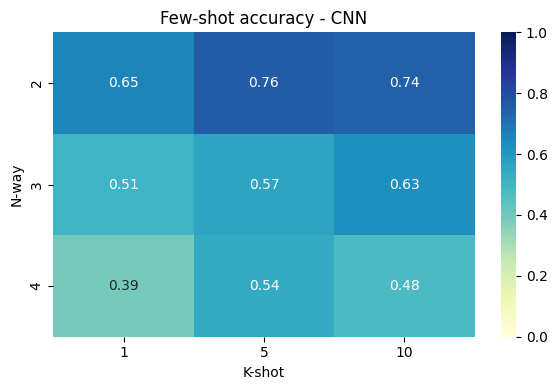

In [78]:
plot_heatmap(cnn_results_df, "CNN", "cnn_heatmap.png")

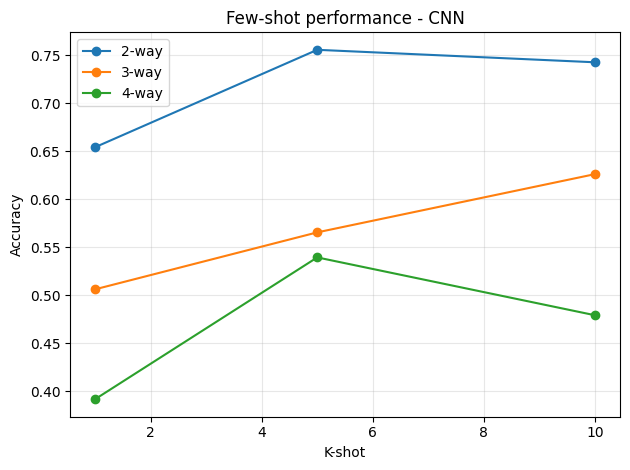

In [81]:
plot_difficulty(cnn_results_df, "CNN")

In [53]:
cnn_results_df

,episodes,N,K,Q,accuracy
0,500,2,1,1,0.654000
1,500,2,5,5,0.755500
2,500,2,10,10,0.742500
3,500,3,1,1,0.506000
4,500,3,5,5,0.565333
5,500,3,10,10,0.626000
6,500,4,1,1,0.391500
7,500,4,5,5,0.539250
8,500,4,10,10,0.479000


### MobileNetV2

In [54]:
mobilenet_results_df = pd.read_csv(os.path.join(RESULT_DIR, "mobilenet_results.csv"))

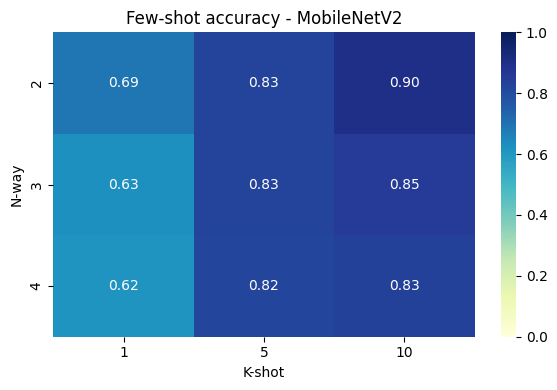

In [82]:
plot_heatmap(mobilenet_results_df, "MobileNetV2", "mobilenet_heatmap.png")

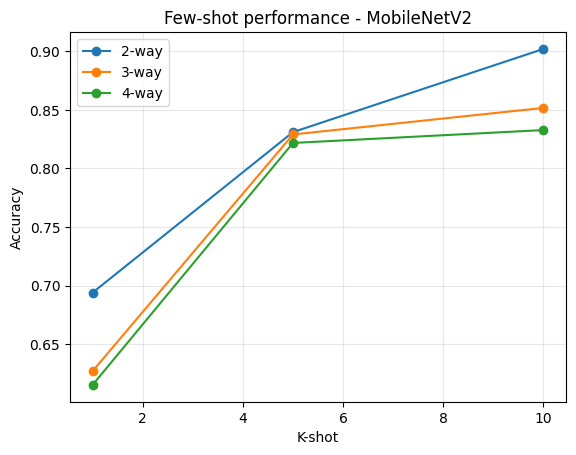

In [56]:
plot_difficulty(mobilenet_results_df, "MobileNetV2")

In [57]:
mobilenet_results_df

,episodes,N,K,Q,accuracy
0,500,2,1,1,0.694000
1,500,2,5,5,0.831000
2,500,2,10,10,0.902000
3,500,3,1,1,0.627000
4,500,3,5,5,0.829000
5,500,3,10,10,0.851667
6,500,4,1,1,0.615250
7,500,4,5,5,0.821750
8,500,4,10,10,0.832750


### ResNet18

In [58]:
resnet_results_df = pd.read_csv(os.path.join(RESULT_DIR, "resnet_results.csv"))

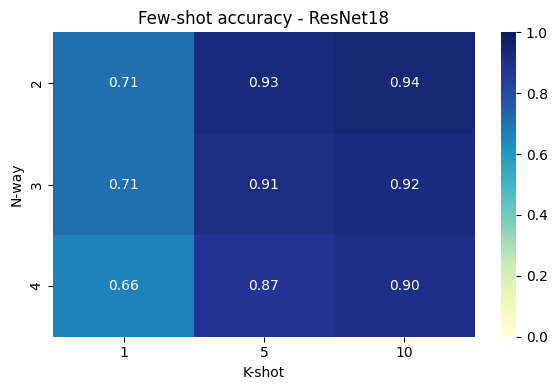

In [83]:
plot_heatmap(resnet_results_df, "ResNet18", "resnet_heatmap.png")

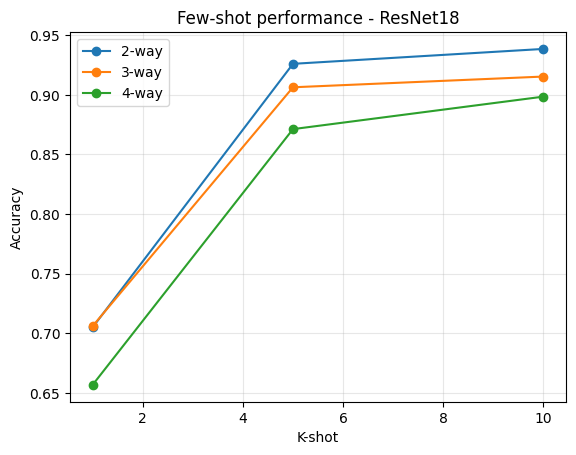

In [60]:
plot_difficulty(resnet_results_df, "ResNet18")

In [61]:
resnet_results_df

,episodes,N,K,Q,accuracy
0,500,2,1,1,0.705000
1,500,2,5,5,0.926000
2,500,2,10,10,0.938500
3,500,3,1,1,0.706000
4,500,3,5,5,0.906333
5,500,3,10,10,0.915333
6,500,4,1,1,0.656750
7,500,4,5,5,0.871250
8,500,4,10,10,0.898500
